In [ ]:
import numpy as np
import pandas as pd
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")

In [ ]:
file_path = '/content/drive/MyDrive/IMDB Sentiment Analysis/IMDB Dataset.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.shape

(50000, 2)

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra whitespace
    return text

In [ ]:
df['clean_text'] = df['review'].apply(clean_text)

In [ ]:
df.head()

,review,sentiment,clean_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


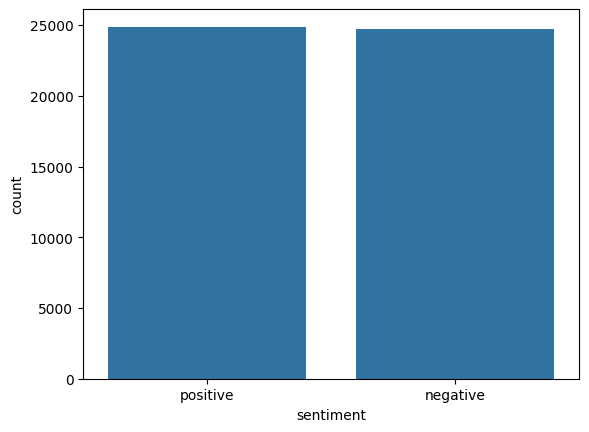

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'sentiment' column
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

# Display the first few rows to verify the new column
display(df.head())

,review,sentiment,clean_text,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,1


In [ ]:
X = df['clean_text'].values
y = df['sentiment_encoded'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Tokenization
max_words = 25000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


In [ ]:
# Convert text to sequence of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
# vocabulary size

vocab_size = len(tokenizer.word_index) + 1
vocab_size

187084

In [ ]:
# Padding
max_seq_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_seq_len, padding='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_seq_len, padding='pre')

In [ ]:
print("Shape Training Review Data: " + str(X_train_pad.shape))
print("Shape Training Class Data: " + str(y_train.shape))
print("Shape Test Review Data: " + str(X_test_pad.shape))
print("Shape Test Class Data: " + str(y_test.shape))


Shape Training Review Data: (39665, 200)
Shape Training Class Data: (39665,)
Shape Test Review Data: (9917, 200)
Shape Test Class Data: (9917,)


**I am doing sentiment analysis classification so i care only about the
    overall meaning of the sentence, not intermediate outputs for each word.**

In [ ]:
# build the RNN

embedding_dim = 100
rnn_units = 32

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_seq_len,)),
    SimpleRNN(units=rnn_units),
    Dense(32, activation='relu'),

    Dropout(0.5),
    Dense(1, activation='sigmoid')
])



rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 100)       │    18,708,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,713,745 (71.39 MB)

 Trainable params: 18,713,745 (71.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # Build Simple RNN Model
# model = Sequential([


#     Embedding(input_dim=max_vocab, output_dim=128, input_shape=(max_len,)),

#     SimpleRNN(64, return_sequences=False),     # return_sequences=False:  Returns only the last hidden state of the RNN sequence.
#     Dropout(0.5),
#     Dense(64, activation='tanh'),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.summary()


In [ ]:
# Train Model
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=128
)


Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7004 - loss: 0.5527 - val_accuracy: 0.8344 - val_loss: 0.4272
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8828 - loss: 0.3177 - val_accuracy: 0.8638 - val_loss: 0.3458
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9294 - loss: 0.2052 - val_accuracy: 0.8560 - val_loss: 0.3588
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9663 - loss: 0.1114 - val_accuracy: 0.8445 - val_loss: 0.4417
Epoch 5/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9831 - loss: 0.0597 - val_accuracy: 0.8474 - val_loss: 0.5304
Epoch 6/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9891 - loss: 0.0385 - val_accuracy: 0.8395 - val_loss: 0.6727
Epoch 7/10
205/310 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9811 - loss: 0.0600

KeyboardInterrupt: 

In [ ]:
# Evaluate Model
loss, accuracy = rnn_model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


# LSTM


In [ ]:
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Concatonate test and training datasets
allreviews = np.concatenate((x_train, x_test), axis=0)

# Review lengths across test and training whole datasets
print("Maximum review length: {}".format(len(max((allreviews), key=len))))
print("Minimum review length: {}".format(len(min((allreviews), key=len))))
result = [len(x) for x in allreviews]
print("Mean review length: {}".format(np.mean(result)))


Maximum review length: 2494
Minimum review length: 7
Mean review length: 234.75892


In [ ]:

# Print a review and it's class as stored in the dataset. Replace the number
# to select a different review.
print("")
print("Machine readable Review")
print("  Review Text: " + str(x_train[60]))
print("  Review Sentiment: " + str(y_train[60]))


Machine readable Review
  Review Text: [1, 13, 219, 14, 33, 4, 2, 22, 1413, 12, 16, 373, 175, 2711, 1115, 1026, 430, 939, 16, 23, 2444, 25, 43, 697, 89, 12, 16, 170, 8, 130, 262, 19, 32, 4, 665, 7, 4, 2, 322, 5, 4, 1520, 7, 4, 86, 250, 10, 10, 4, 249, 173, 16, 4, 3891, 6, 19, 4, 167, 564, 5, 564, 1325, 36, 805, 8, 216, 638, 17, 2, 21, 25, 100, 376, 507, 4, 2110, 15, 79, 125, 23, 567, 13, 2134, 233, 36, 4852, 2, 5, 81, 1672, 10, 10, 92, 437, 129, 58, 13, 69, 8, 401, 61, 1432, 39, 1286, 46, 7, 12]
  Review Sentiment: 0


In [ ]:
# The length of reviews
review_length = 500

# Padding / truncated our reviews
x_train = sequence.pad_sequences(x_train, maxlen = review_length)
x_test = sequence.pad_sequences(x_test, maxlen = review_length)

In [ ]:
print("Shape Training Review Data: " + str(x_train.shape))
print("Shape Training Class Data: " + str(y_train.shape))
print("Shape Test Review Data: " + str(x_test.shape))
print("Shape Test Class Data: " + str(y_test.shape))

Shape Training Review Data: (25000, 500)
Shape Training Class Data: (25000,)
Shape Test Review Data: (25000, 500)
Shape Test Class Data: (25000,)


In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_shape=(review_length,)),
    LSTM(units=32),
    Dropout(0.25),
    Dense(units=1, activation='sigmoid')
])


# Compile the model
model.compile(
    loss=tf.keras.losses.binary_crossentropy, # loss function
    optimizer=tf.keras.optimizers.Adam(), # optimiser function
    metrics=['accuracy']) # reporting metric

# Display a summary of the models structure
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

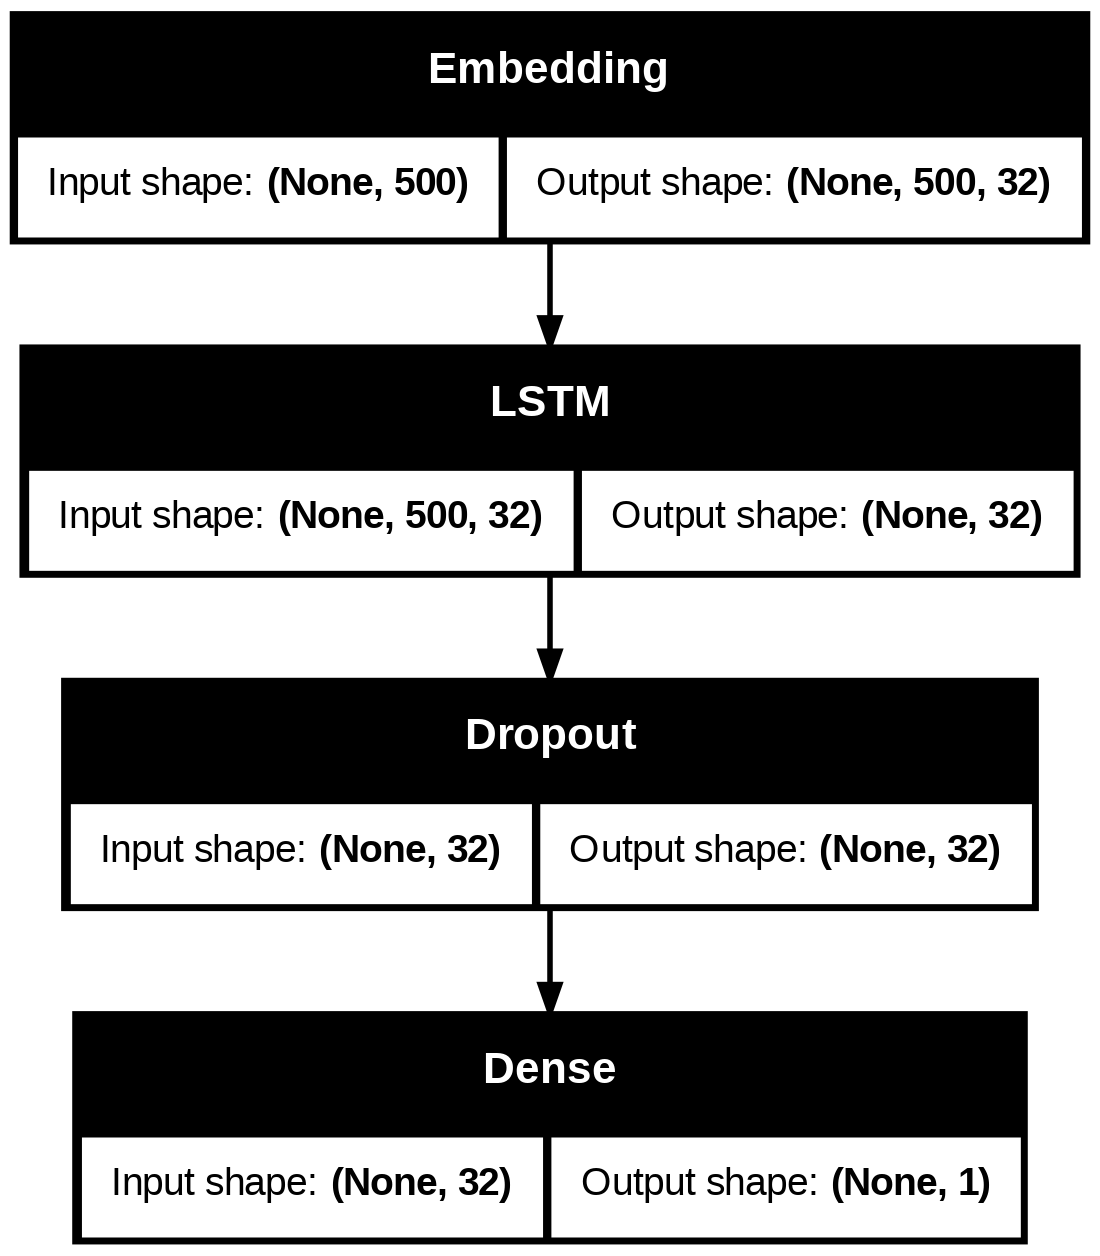

In [ ]:
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=False)

In [ ]:
# Train the LSTM on the training data
history = model.fit(

    # Training data : features (review) and classes (positive or negative)
    x_train, y_train,

    # Number of samples to work through before updating the
    # internal model parameters via back propagation. The
    # higher the batch, the more memory you need.
    batch_size=256,

    # An epoch is an iteration over the entire training data.
    epochs=10,

    # The model will set apart his fraction of the training
    # data, will not train on it, and will evaluate the loss
    # and any model metrics on this data at the end of
    # each epoch.
    validation_split=0.2,

    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6120 - loss: 0.6590 - val_accuracy: 0.7908 - val_loss: 0.4690
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8375 - loss: 0.3821 - val_accuracy: 0.8560 - val_loss: 0.3473
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9019 - loss: 0.2593 - val_accuracy: 0.8850 - val_loss: 0.3040
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9354 - loss: 0.1876 - val_accuracy: 0.8784 - val_loss: 0.2971
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9524 - loss: 0.1493 - val_accuracy: 0.8796 - val_loss: 0.3096
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9594 - loss: 0.1280 - val_accuracy: 0.8560 - val_loss: 0.3325
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9574 - loss: 0.1320 - val_accuracy: 0.8786 - val_loss: 0.3475
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9724 - loss: 0.0916 - val_accuracy: 0.8750 - v

In [ ]:
# Get Model Predictions for test data
from sklearn.metrics import classification_report


y_probs = model.predict(x_test)
# Convert probabilities to class labels (0 or 1)
predicted_classes = (y_probs > 0.5).astype("int32").flatten()
# Classification report
class_names = ["Negative", "Positive"]
print(classification_report(y_test, predicted_classes, target_names=class_names))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     12500
    Positive       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



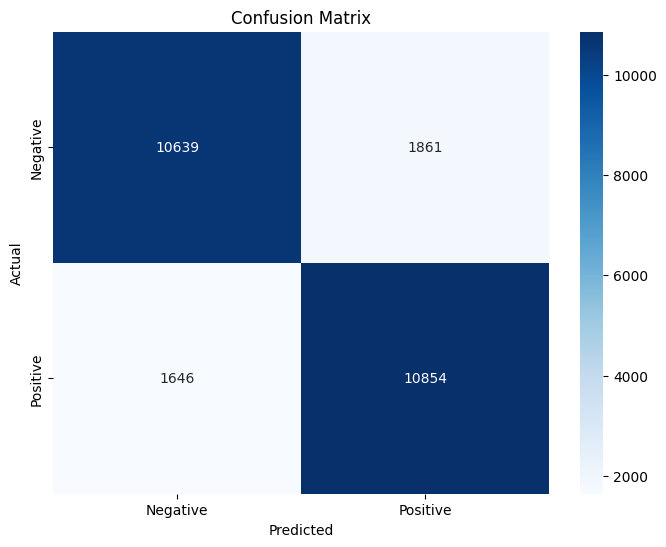

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Load the same word index used in training

from tensorflow.keras.datasets import imdb


word_index = imdb.get_word_index()
index_word = {v + 3: k for k, v in word_index.items()}  # +3 for special tokens
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def encode_review(text):
    # Convert words to word indices (same as training)
    words = text.lower().split()
    encoded = [1]  # start token
    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown token
    return encoded

In [ ]:
def predict_sentiment(text):
    encoded = encode_review(text)
    padded = pad_sequences([encoded], maxlen=review_length)
    prob = model.predict(padded)[0][0]
    sentiment = "Positive" if prob > 0.5 else "Negative"
    return sentiment, prob

In [ ]:
# Example reviews
reviews = [
    "This movie was absolutely fantastic, I loved it",
    "The film was boring and too long. I wouldn't recommend it",
    "An average movie with some good and some bad parts",
    "Terrible acting, terrible plot. One of the worst movies ever",
    "Amazing performances, touching story, and beautiful visuals"
]


In [ ]:
# Run predictions
for review in reviews:
    sentiment, prob = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {prob:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Review: This movie was absolutely fantastic, I loved it
Predicted Sentiment: Positive (Confidence: 0.8303)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Review: The film was boring and too long. I wouldn't recommend it
Predicted Sentiment: Negative (Confidence: 0.0818)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: An average movie with some good and some bad parts
Predicted Sentiment: Negative (Confidence: 0.4834)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Review: Terrible acting, terrible plot. One of the worst movies ever
Predicted Sentiment: Negative (Confidence: 0.0022)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: Amazing performances, touching story, and beautiful visuals
Predicted Sentiment: Positive (Confidence: 0.9930)

